In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [19]:
TS = pd.read_csv('Milk_Production_train.csv', parse_dates=['date'], index_col='date')
TS_test = pd.read_csv('Milk_Production_test.csv')

In [20]:
TS

,Milk(pounds)
date,
1962-01-01,589.0
1962-02-01,561.0
1962-03-01,640.0
1962-04-01,656.0
1962-05-01,727.0
...,...
1969-08-01,764.0
1969-09-01,725.0
1969-10-01,723.0


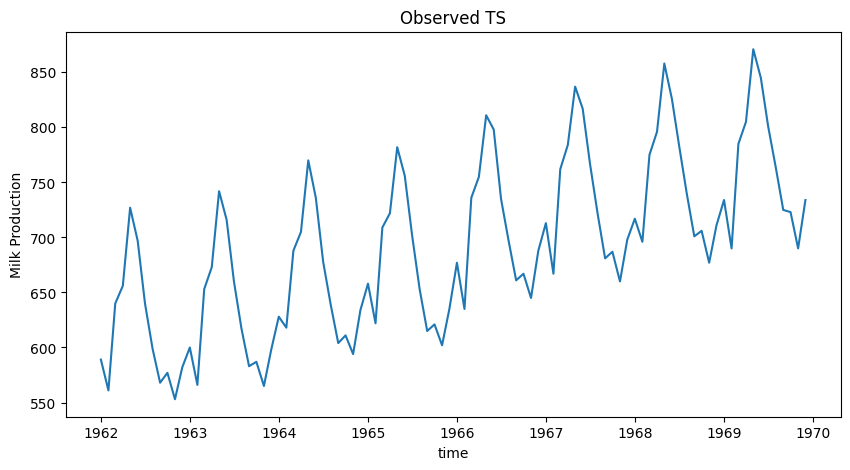

In [21]:
#plotting the TS data
plt.figure(figsize=(10, 5))
plt.plot(TS)
plt.title("Observed TS")
plt.xlabel("time")
plt.ylabel("Milk Production")
plt.show()

# #The TS isn't stationnary is variance nor in mean, the type of serie we have here is an additive one, as it's doesn't grow exponentially each year which would make it multiplicative.

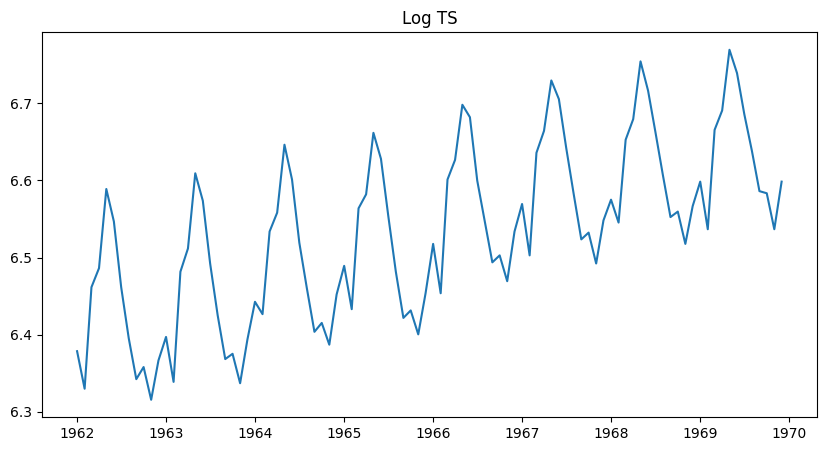

In [22]:
#We may want to test to apply log function on the data to see if any change occurs
TS_log = np.log(TS)
plt.figure(figsize=(10, 5))
plt.plot(TS_log)
plt.title("Log TS")
plt.show()

# #As we can see no change occured, the serie stayed as it is
there are cases where it does change, but this happens mostly when the data is multiplicative
what will be much more efficient is to check the rolling-mean of the data
this provides us whith a better idea on how the serie evolves in the average

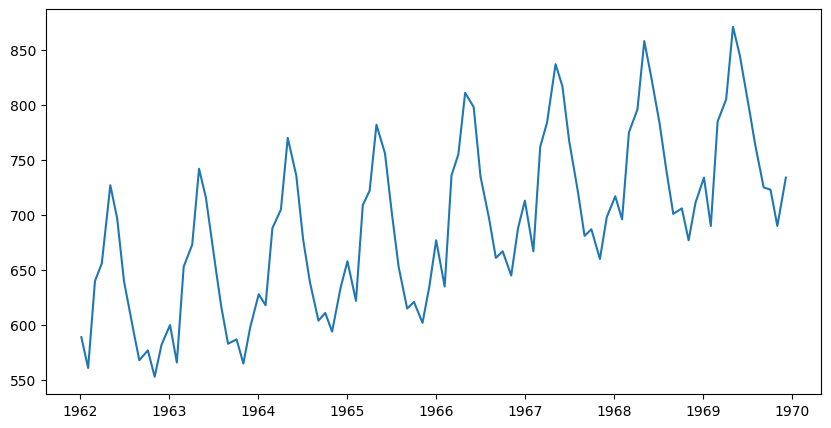

In [23]:
#After trying log proprety and seeing no prior change,before seeing the rolling mean we want to upsample to see how the data evolves in a weekly frame
resampled_TS = TS.resample('W').mean().interpolate()
plt.figure(figsize=(10, 5))
plt.plot(resampled_TS)
plt.show()

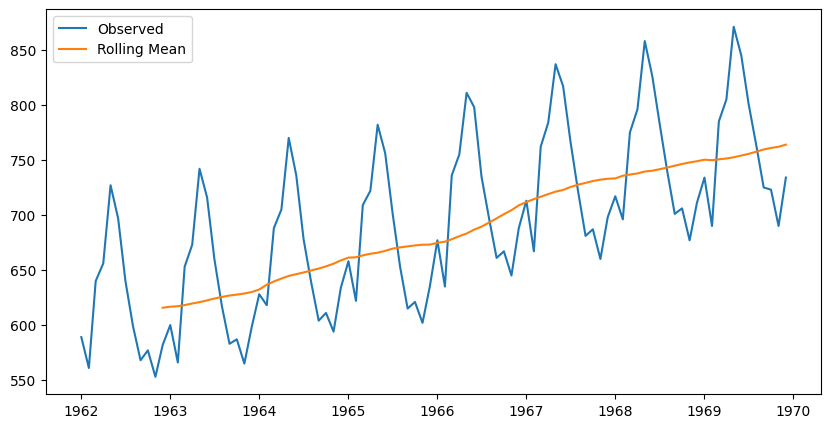

In [24]:
rolling_mean = TS.rolling(12).mean()
plt.figure(figsize=(10, 5))
plt.plot(TS, label='Observed')
plt.plot(rolling_mean, label='Rolling Mean')
plt.legend()
plt.show()

# #We notice the the rolling mean evolves with the serie, which confirms before using test that the series doesn't have a constant mean (thus non stat)

We'll use STL for further analysis

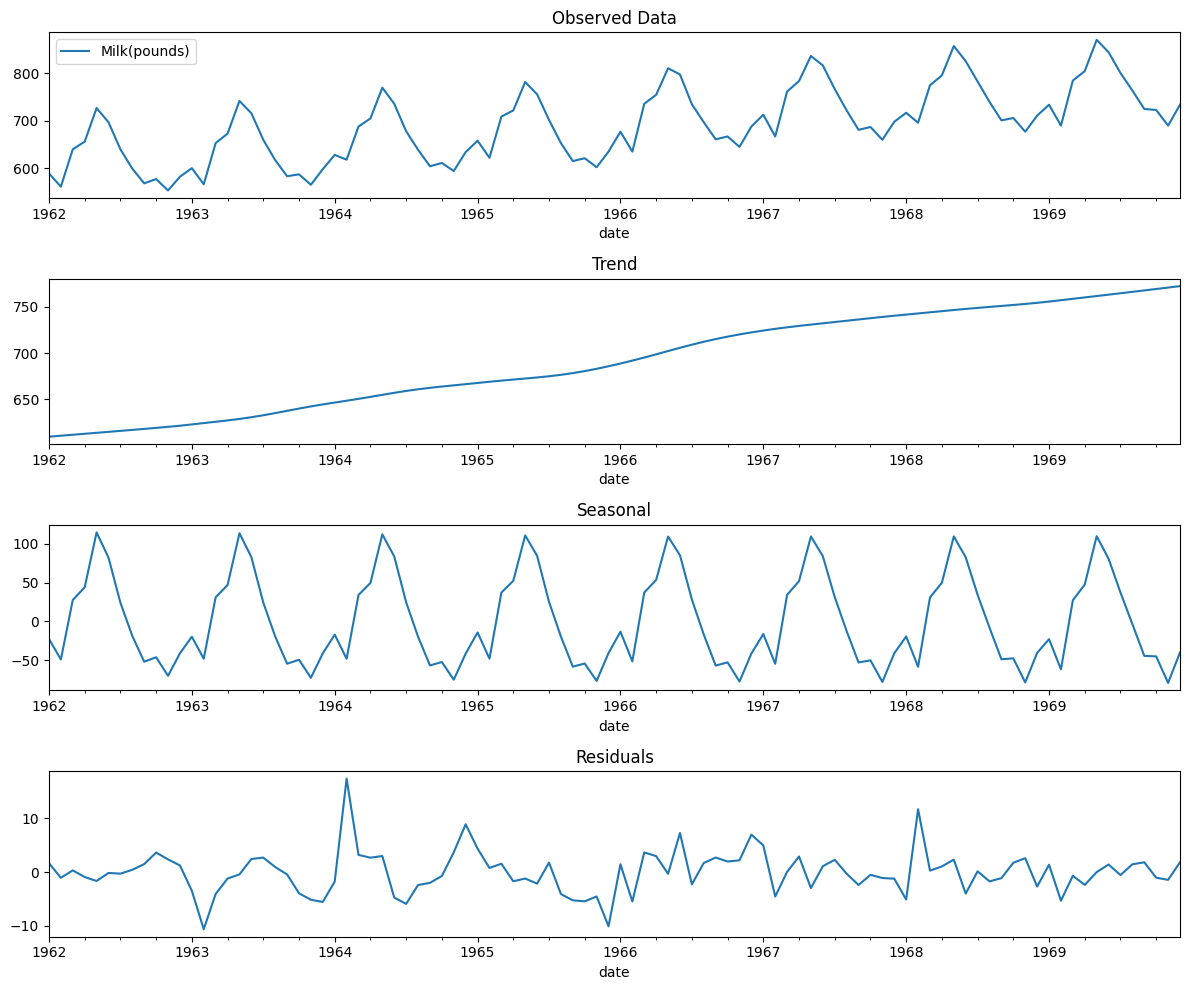

In [25]:
decomp_TS = STL(TS, period=12).fit()

fig, ax = plt.subplots(4, 1, figsize=(12,10))
decomp_TS.observed.plot(ax=ax[0], title='Observed Data')
decomp_TS.trend.plot(ax=ax[1], title='Trend')
decomp_TS.seasonal.plot(ax=ax[2], title='Seasonal')
decomp_TS.resid.plot(ax=ax[3], title='Residuals')
plt.tight_layout()
plt.show()

# #Except the residuals nothing looks stationnary after decomposing the TS
we now confirmed through graphs that the serie isn't stationnary

we'll now use test (and the result will be not stationnary)

In [26]:
def adf_test(serie):
  result = adfuller(serie)
  print(f"ADF Statistic: {result[0]}")
  print(f"p-value: {result[1]}")
  if result[1] > 0.05: #H0: serie not stationnary if p_value greater than 0.05
    print("The serie is not stationary") #H1 opposite
  else:
    print("The serie is stationary")

def kpss_test(serie):
  result = kpss(serie)
  print(f"KPSS Statistic: {result[0]}")
  print(f"p-value: {result[1]}")
  if result[1] < 0.05: #the kpss test suppose the opposite of adf test
    print("The serie is not stationary")
  else:
    print("The serie is stationary")

adf_test(TS)
kpss_test(TS)

ADF Statistic: -0.6749301694670112
p-value: 0.8531367707475414
The serie is not stationary
KPSS Statistic: 1.1323109872517922
p-value: 0.01
The serie is not stationary


/tmp/ipykernel_5713/4149879527.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(serie)


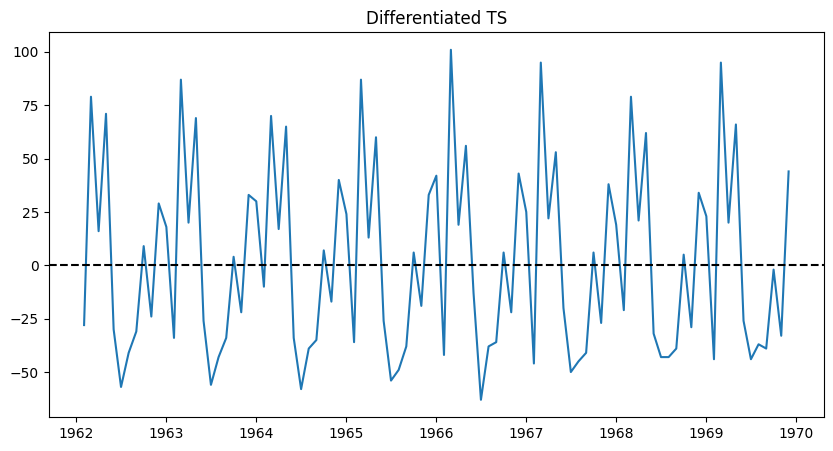

In [27]:
#after concluding definitly non-stationnarity we'll move to differentiating
TS_diff = TS.diff().dropna()
plt.figure(figsize=(10, 5))
plt.plot(TS_diff)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Differentiated TS")
plt.show()

In [28]:
adf_test(TS_diff)
kpss_test(TS_diff)

ADF Statistic: -2.8183780855848255
p-value: 0.05569616427542964
The serie is not stationary
KPSS Statistic: 0.02089475087652681
p-value: 0.1
The serie is stationary


/tmp/ipykernel_5713/4149879527.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(serie)


# #The serie may appear stationanry, especially after one of the tests did say that it is (kpss), but we can't just rule using that result
we may want to make another test to decide

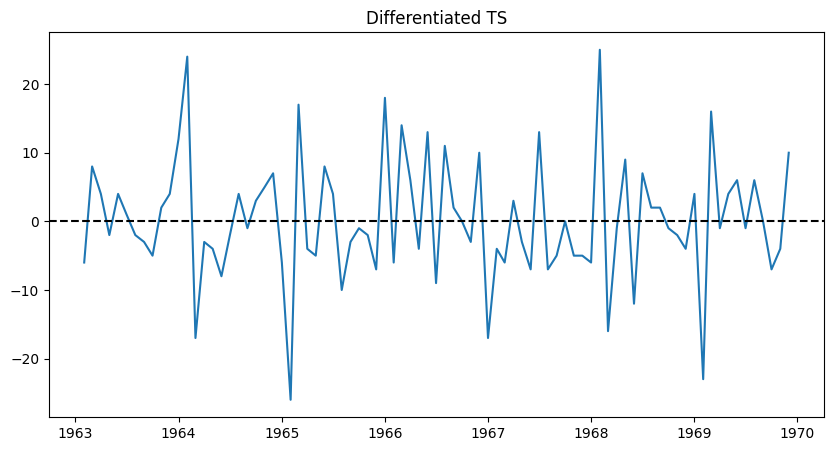

In [29]:
TS_diff_s = TS_diff.diff(12).dropna() #since the data are monthly samples then 12, this will affect seasonality
plt.figure(figsize=(10, 5))
plt.plot(TS_diff_s)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Differentiated TS")
plt.show()

In [30]:
adf_test(TS_diff_s)
kpss_test(TS_diff_s)

ADF Statistic: -4.029544558454292
p-value: 0.0012634683475502239
The serie is stationary
KPSS Statistic: 0.07201880557012245
p-value: 0.1
The serie is stationary


/tmp/ipykernel_5713/4149879527.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(serie)


# #The serie is now stationnary, we can see it with the graph and both the tests confirms it

# #ACF PACF PLOTING

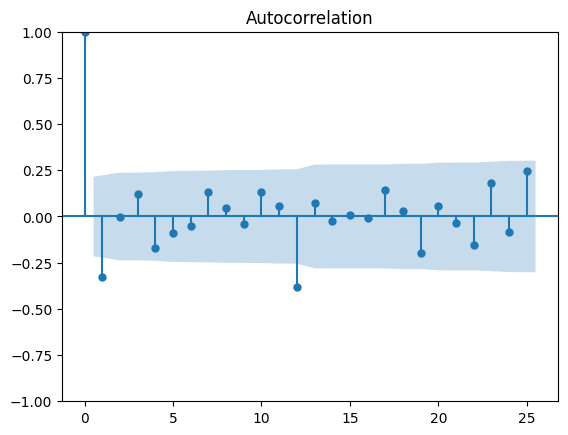

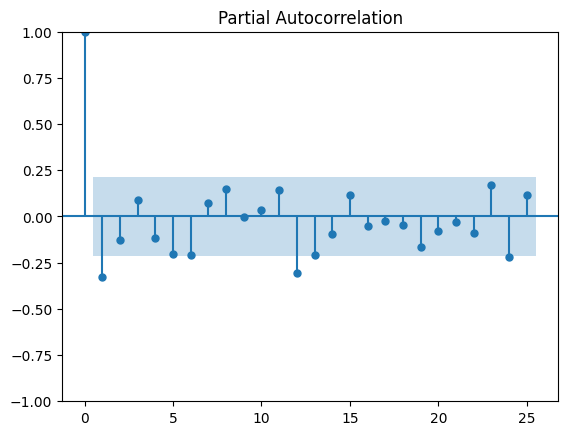

In [31]:
plot_acf(TS_diff_s, lags=25)
plot_pacf(TS_diff_s, lags=25)
plt.show()

We are seeing spikes out the CI in both ACF and PACF

In [32]:
#starting to make the model
model = SARIMAX(TS, order=(1,1,1)) #we start with order (1,1,1) and since we only differ one time then I is 1
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:           Milk(pounds)   No. Observations:                   96
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -492.385
Date:                Tue, 05 May 2026   AIC                            990.771
Time:                        18:46:22   BIC                            998.432
Sample:                    01-01-1962   HQIC                           993.866
                         - 12-01-1969                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3835      0.752      0.510      0.610      -1.090       1.857
ma.L1         -0.2629      0.800     -0.329      0.743      -1.831       1.306
sigma2      1855.0255    392.499      4.726      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


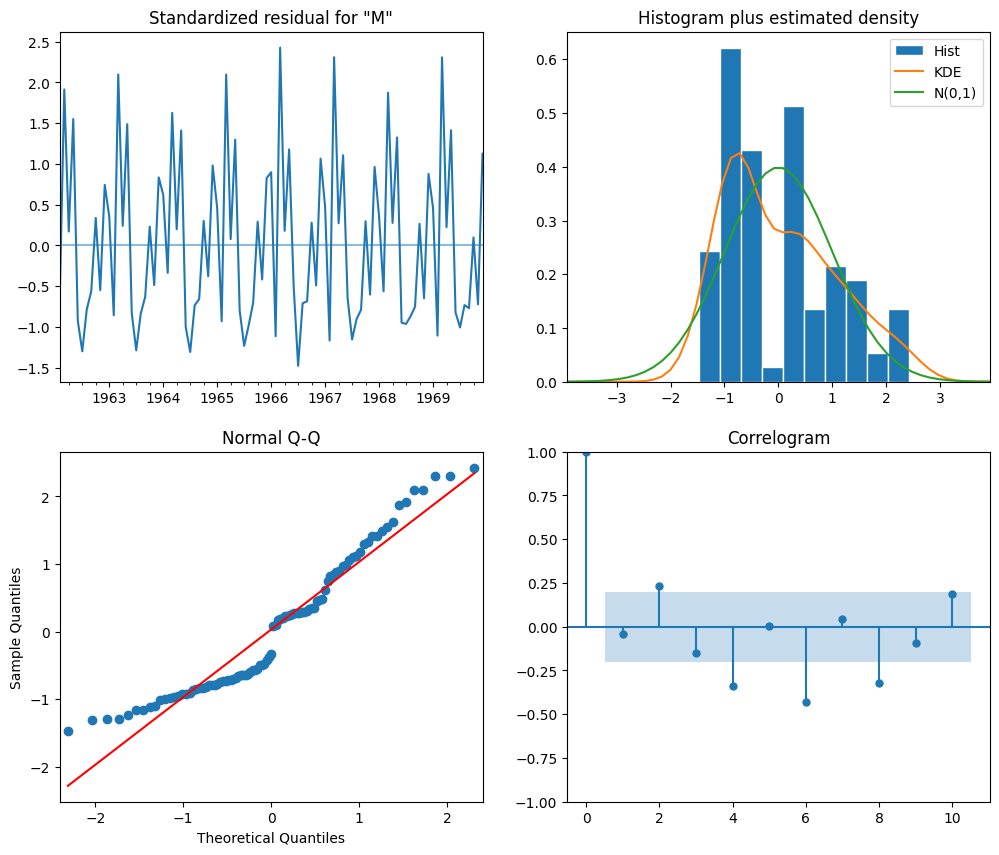

In [33]:
result.plot_diagnostics(figsize=(12, 10))
plt.show()

# #Plot diagnostic
the residuals looks fine (statio)
the histogram doesn't follow a proper normal distribution, it deviates a bit at left side because of the skewness (0.63)
the correlogram is still facing spikes, our model needs to be refined since it isn't yet ready fro forcast

In [34]:
results = []
for p in range(2):
  for q in range(2):
    for P in range(2):
      for Q in range(2):
        model = SARIMAX(TS, order=(p,1,q), seasonal_order=(P,1,Q,12))
        result = model.fit()
        results.append((p, q, P, Q, result.aic, result.bic))
        print(f"Seasonal order: p:{p},1,q:{q}, P:{P},1,Q:{Q},12")
        print(f"AIC: {result.aic}, BIC: {result.bic}")
results_df = pd.DataFrame(results, columns=['p', 'q', 'P', 'Q', 'AIC', 'BIC'])
print(results_df.sort_values(by=['AIC']))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Seasonal order: p:0,1,q:0, P:0,1,Q:0,12
AIC: 602.6403310994599, BIC: 605.0591717072565
Seasonal order: p:0,1,q:0, P:0,1,Q:1,12
AIC: 580.9236652360532, BIC: 585.7613464516464
Seasonal order: p:0,1,q:0, P:1,1,Q:0,12
AIC: 590.3639990015783, BIC: 595.2016802171715


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Seasonal order: p:0,1,q:0, P:1,1,Q:1,12
AIC: 582.6204042144177, BIC: 589.8769260378075
Seasonal order: p:0,1,q:1, P:0,1,Q:0,12
AIC: 594.0782284934437, BIC: 598.9159097090369


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

Seasonal order: p:1,1,q:1, P:0,1,Q:1,12
AIC: 574.862913276756, BIC: 584.5382757079424


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Seasonal order: p:1,1,q:1, P:1,1,Q:0,12
AIC: 578.5286538157657, BIC: 588.204016246952


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Seasonal order: p:1,1,q:1, P:1,1,Q:1,12
AIC: 576.8626417122291, BIC: 588.9568447512121
    p  q  P  Q         AIC         BIC
5   0  1  0  1  572.876517  580.133039
9   1  0  0  1  573.722221  580.978743
13  1  1  0  1  574.862913  584.538276
7   0  1  1  1  574.875400  584.550762
11  1  0  1  1  575.706088  585.381450
15  1  1  1  1  576.862642  588.956845
10  1  0  1  0  577.216639  584.473160
6   0  1  1  0  577.620442  584.876964
14  1  1  1  0  578.528654  588.204016
1   0  0  0  1  580.923665  585.761346
3   0  0  1  1  582.620404  589.876926
2   0  0  1  0  590.363999  595.201680
4   0  1  0  0  594.078228  598.915910
8   1  0  0  0  594.993530  599.831211
12  1  1  0  0  596.066126  603.322648
0   0  0  0  0  602.640331  605.059172


# # #We'll take the smallest AIC AND BIC
#but mostly focus on smallest BIC as it penalizes more
#result:

               p  q  P  Q     AIC        BIC
               0  1  0  1  572.876517  580.133039

In [35]:
model = SARIMAX(TS, order=(0,1,1), seasonal_order=(0,1,1,12))
result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       Milk(pounds)   No. Observations:                   96
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -283.438
Date:                            Tue, 05 May 2026   AIC                            572.877
Time:                                    18:46:28   BIC                            580.133
Sample:                                01-01-1962   HQIC                           575.792
                                     - 12-01-1969                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3565      0.114     -3.136      0.002      -0.579      -0.134
ma.S.L12      -0.6452      0.116   

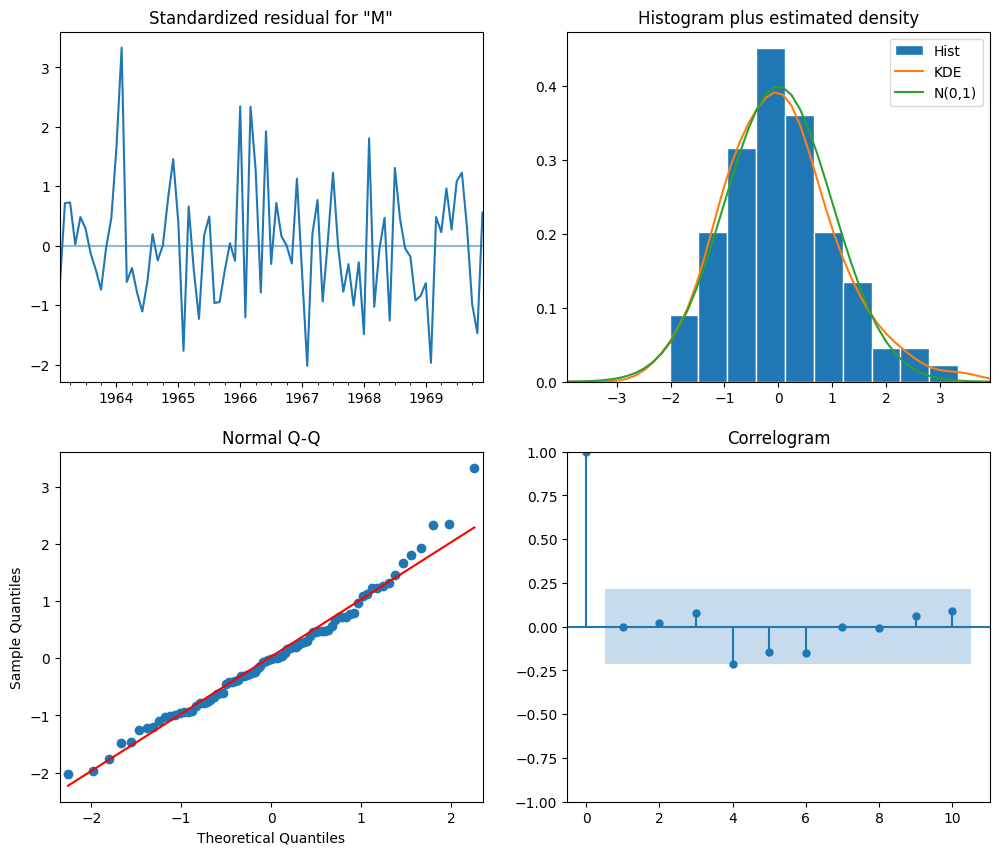

In [37]:
result.plot_diagnostics(figsize=(12,10))
plt.show()

# #Plot diagnostic2
Since the last diagnostic, our model looks better in the corelogram and the distribution and also the regressed line

In [38]:
TS_test['date'] = pd.to_datetime(TS_test['date'])
TS_test = TS_test.set_index('date')

model_res = SARIMAX(TS, order=(0,1,1), seasonal_order=(0,1,1,12))
result_res = model_res.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [39]:
forcast = result_res.get_forecast(steps=len(TS_test))
predicted_mean = forcast.predicted_mean
conf_int = forcast.conf_int()

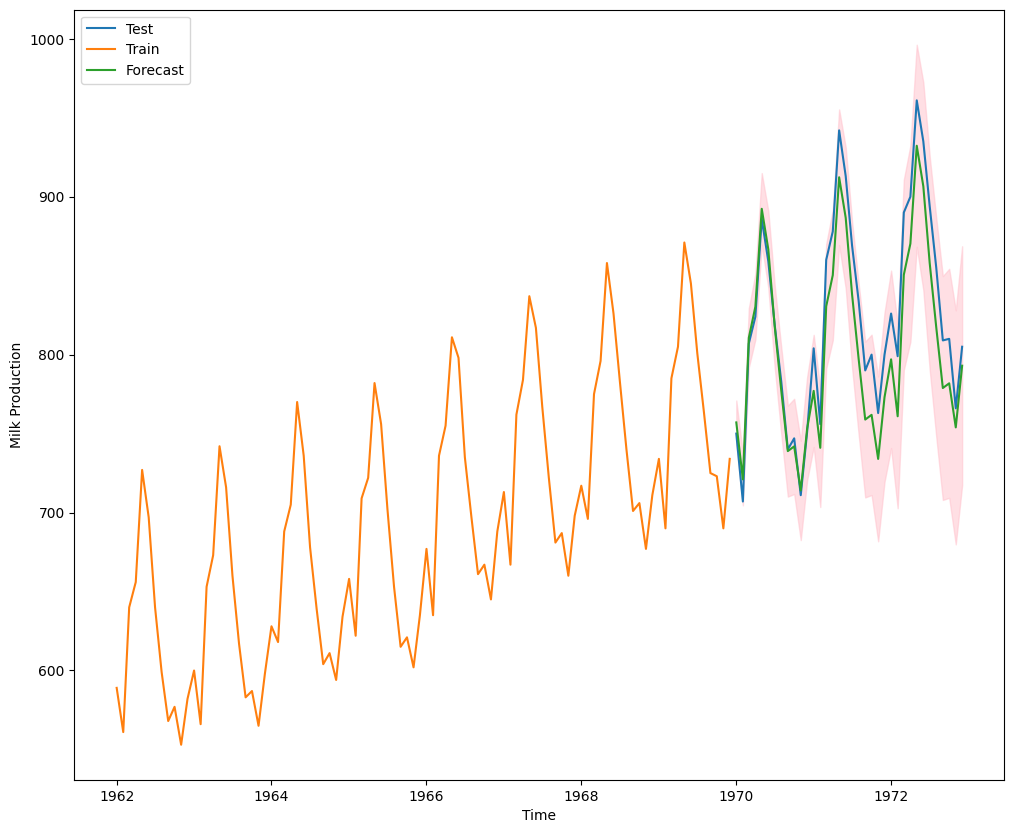

In [40]:
plt.figure(figsize=(12,10))
plt.plot(TS_test, label='Test')
plt.plot(TS, label='Train')
plt.plot(predicted_mean, label='Forecast')

plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.5)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.show()

In [41]:
MAE = mean_absolute_error(TS_test, predicted_mean)
RMSE = np.sqrt(mean_squared_error(TS_test, predicted_mean))

print(f"MAE: {MAE}")
print(f"RMSE: {RMSE}")

MAE: 21.117551113862525
RMSE: 24.717136586805694


# #Final results
we were able to stationnarize our TS
made the model better than how it'd be if we trained it before without running a test on different degrees of SARIMAX
the forcast itself isn't only enough but what we look prescisely is the CI, we see that our forcast falls within the CI whihc suggest that our model performance is raisonnable.